# Lab 6: Logistic Regression & KNN

**Name:** Manahil Fatima  

**Student ID:** 023-24-0249

**Section:** H

**GitHub:** https://github.com/ManahilFatima16/ml-lab6-logreg-knn-churn  

**Kaggle:** https://www.kaggle.com/manahilmemon12  

**Dataset:** http://kaggle.com/datasets/blastchar/telco-customer-churn

**Target variable:** Churn (Yes/No)

## Part 1 — Problem Definition & Dataset Verification

In [6]:
#Task 1 
import pandas as pd
import numpy as np
df_clean = pd.read_csv('clean_churn.csv')
print(df_clean.shape)
df_clean.info()
df_clean['Churn'].value_counts(normalize=True)

(7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

**Task 2:**

In Lab 3, my Decision Tree (max_depth=5) achieved 0.7942 accuracy, 0.6313 precision, 0.5401 recall, and 0.5821 F1-score on the test set. In Lab 4, the tuned Random Forest (n_estimators=200, max_depth=10, min_samples_split=2) improved this to 0.8048 accuracy, 0.6623 precision, 0.5401 recall, and 0.5950 F1-score. Cross-validation in Lab 4 also showed Random Forest generalizes more consistently (mean F1 = 0.558, std = 0.020) than the Decision Tree (mean F1 = 0.516, std = 0.035). These four numbers are today's benchmarks.

## Part 2 — Feature Scaling & Preparation

In [11]:
#Task 3
y = df_clean["Churn"].map({"Yes": 1, "No": 0})
X = df_clean.drop(columns=["Churn"])

X = pd.get_dummies(X, columns = [
  "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"  
], drop_first=True)

**Task 4:**

My Decision Tree and Random Forest split on a threshold of one raw feature at a time (e.g. tenure < 12), so scale never mattered a split at "tenure < 12" is the same decision whether tenure is in months or scaled units. Logistic Regression and KNN are different: KNN computes Euclidean distance across all features simultaneously, so TotalCharges (range roughly 0–8000+) would completely dominate a dummy variable like Contract_Two year (0 or 1) unless everything is on a comparable scale. Logistic Regression also converges faster and gives coefficients that are only comparable to each other once features are scaled.


In [12]:
#Task 5 - split 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(5634, 30) (1409, 30) (5634,) (1409,)


I fit the scaler only on X_train and reused it to transform X_test because fitting on the full dataset before splitting would leak information about the test set's distribution into training, making the test performance estimate too optimistic the same data-leakage risk we've been careful about since Lab 2/3.

## Part 3 — Logistic Regression

In [17]:
#Task 6
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000,random_state=42)
logreg.fit(X_train_scaled,y_train)
logreg_pred = logreg.predict(X_test_scaled)


Logistic Regression Results
     Metrics     Score
0   Accuracy  0.806955
1  Precision  0.658385
2     Recall  0.566845
3   F1-Score  0.609195


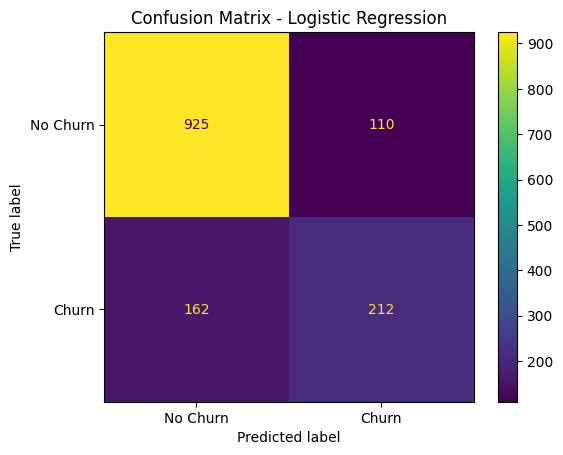

[[0.95501784 0.04498216]
 [0.31676582 0.68323418]
 [0.94345828 0.05654172]
 [0.59219449 0.40780551]
 [0.97833433 0.02166567]]


In [22]:
#Task 6
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_pred = logreg.predict(X_test_scaled)

#Task 7
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logreg_acc = accuracy_score(y_test, logreg_pred)
logreg_prec = precision_score(y_test, logreg_pred)
logreg_rec = recall_score(y_test, logreg_pred)
logreg_f1 = f1_score(y_test, logreg_pred)

print("Logistic Regression Results")
print(pd.DataFrame({
    'Metrics': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [logreg_acc, logreg_prec, logreg_rec, logreg_f1]
}))

cm_lr = confusion_matrix(y_test, logreg_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['No Churn', 'Churn']).plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#Task 8 
probs = logreg.predict_proba(X_test_scaled)[:5]
print(probs)

predict_proba gives the estimated probability that a customer falls into each class e.g. [0.71, 0.29] means a 71% estimated chance of not churning. .predict() just applies a 0.5 threshold to the second column: if P(Churn) ≥ 0.5, it outputs 1 (Yes), otherwise 0 (No).

## Part 4 — KNN & Choosing K

    K  Accuracy  F1-score
0   1  0.716111  0.476440
1   3  0.743790  0.512821
2   5  0.747339  0.512329
3   7  0.759404  0.532414
4   9  0.769340  0.557823
5  11  0.772889  0.561644
6  15  0.770050  0.554945
7  21  0.770759  0.561737


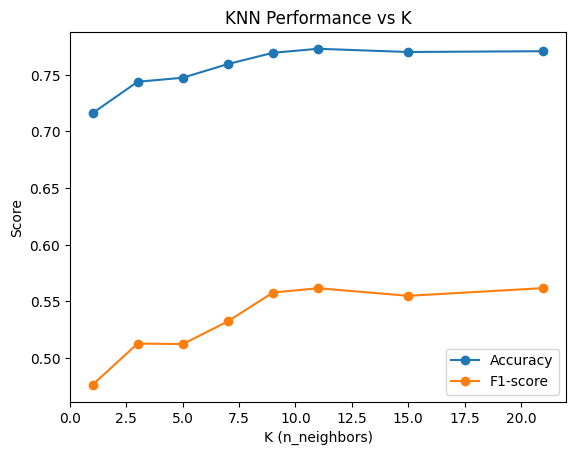

In [23]:
#Task 9
from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_pred_k = knn.predict(X_test_scaled)
    knn_results.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, knn_pred_k),
        'F1-score': f1_score(y_test, knn_pred_k)
    })

knn_results_df = pd.DataFrame(knn_results)
print(knn_results_df)

#Task 10 - plot accuracy/F1 vs K
plt.plot(knn_results_df['K'], knn_results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(knn_results_df['K'], knn_results_df['F1-score'], marker='o', label='F1-score')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K')
plt.legend()
plt.show()

**Task 10:**

Accuracy and F1-score both go up fast from K=1 to K=9, then level off. Accuracy is best at K=11 (0.773). F1-score is basically tied between K=11 and K=21 (0.5616 vs 0.5617  barely any difference).

I choose K=11.

K=1 is too small it just memorizes the closest single point, so it's noisy and overfits (same problem as the unrestricted Decision Tree in Lab 3). K=21 is too large it barely improves F1 and averages over too many neighbors, which risks drowning out the minority "churn" class. K=11 gives the best accuracy and matches the best F1, so it's the best trade-off without going too far in either direction.

KNN Final Model (K=11)
     Metrics     Score
0   Accuracy  0.772889
1  Precision  0.575843
2     Recall  0.548128
3   F1-Score  0.561644


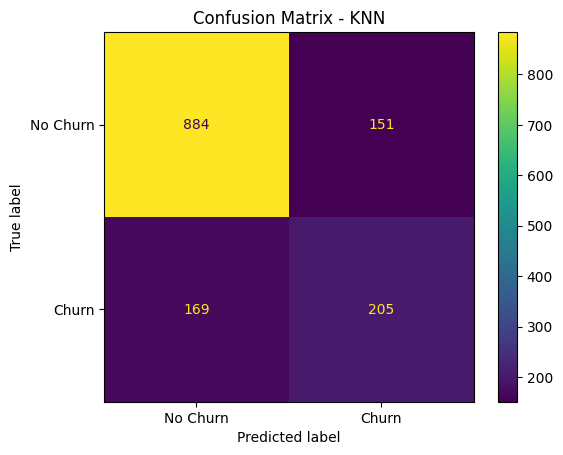

In [25]:
#Task 11
best_k = 11  

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_final_pred = knn_final.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_final_pred)
knn_prec = precision_score(y_test, knn_final_pred)
knn_rec = recall_score(y_test, knn_final_pred)
knn_f1 = f1_score(y_test, knn_final_pred)

print("KNN Final Model (K=%s)" % best_k)
print(pd.DataFrame({
    'Metrics': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [knn_acc, knn_prec, knn_rec, knn_f1]
}))

cm_knn = confusion_matrix(y_test, knn_final_pred)
ConfusionMatrixDisplay(cm_knn, display_labels=['No Churn', 'Churn']).plot()
plt.title('Confusion Matrix - KNN')
plt.show()

With K=11, the final KNN model correctly classifies about 77% of customers overall. Of the customers it predicts will churn, ~58% actually do (precision), and it catches about 55% of all actual churners (recall). This is a solid improvement over K=1, but still misses a meaningful chunk of real churners visible in the confusion matrix as false negatives (churn customers predicted "No Churn").

## Part 5 — Model Comparison (4 Models)

In [26]:
#Task 12
final_comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Decision Tree (Lab 3)': [0.794180, 0.631250, 0.540107, 0.582133],
    'Random Forest - Tuned (Lab 4)': [0.804826, 0.662295, 0.540107, 0.594993],
    'Logistic Regression (Lab 6)': [logreg_acc, logreg_prec, logreg_rec, logreg_f1],
    'KNN (Lab 6)': [knn_acc, knn_prec, knn_rec, knn_f1]
})
print(final_comparison_df)

      Metric  Decision Tree (Lab 3)  Random Forest - Tuned (Lab 4)  \
0   Accuracy               0.794180                       0.804826   
1  Precision               0.631250                       0.662295   
2     Recall               0.540107                       0.540107   
3   F1-score               0.582133                       0.594993   

   Logistic Regression (Lab 6)  KNN (Lab 6)  
0                     0.806955     0.772889  
1                     0.658385     0.575843  
2                     0.566845     0.548128  
3                     0.609195     0.561644  


**Task 13:**

Logistic Regression wins on accuracy (0.807), recall (0.567), and F1 (0.609) beating all other models on 3 of 4 metrics. Random Forest only edges it out on precision (0.662 vs 0.658). Since recall/F1 matter most here due to class imbalance, Logistic Regression is the best model overall, beating my previous best (Random Forest, F1=0.595) by ~0.014 F1.

## Part 6 — Coefficient Interpretation

In [27]:
coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
})
coef_table['Odds Ratio'] = np.exp(coef_table['Coefficient'])
coef_table = coef_table.sort_values('Coefficient', ascending=False)
print(coef_table)

                                  Feature  Coefficient  Odds Ratio
10            InternetService_Fiber optic     0.776154    2.173099
2                            TotalCharges     0.514285    1.672442
23                    StreamingMovies_Yes     0.257227    1.293338
21                        StreamingTV_Yes     0.257144    1.293231
9                       MultipleLines_Yes     0.216167    1.241310
26                   PaperlessBilling_Yes     0.182034    1.199655
28         PaymentMethod_Electronic check     0.181103    1.198539
4                       SeniorCitizen_Yes     0.053073    1.054507
17                   DeviceProtection_Yes     0.053048    1.054480
29             PaymentMethod_Mailed check     0.032262    1.032788
3                             gender_Male     0.011094    1.011156
5                             Partner_Yes     0.010866    1.010926
7                        PhoneService_Yes     0.006794    1.006817
8          MultipleLines_No phone service    -0.006794    0.99

**Task 14:**

tenure: odds ratio 0.29 → longer tenure = much lower churn odds.

Fiber optic: odds ratio 2.17 → fiber customers churn ~2× more.

Contract_Two year: odds ratio 0.56 → two-year contracts cut churn odds almost in half.

Electronic check: odds ratio 1.20 → electronic check users churn slightly more.

MonthlyCharges: odds ratio 0.40 (negative) → likely just overlapping with tenure/TotalCharges, not a real independent effect

**Task 15:**

Mostly yes,
tenure, Contract, Fiber optic, and Electronic check match Lab 3/4's top features too. 
Only mismatch: MonthlyCharges flips sign here, probably because it overlaps with tenure/TotalCharges, and linear models handle correlated features differently than trees.

## Part 7 — Final Model Selection & Conclusion

**Task 16:**

I select Logistic Regression as my final model. It has the best F1 (0.609) and recall (0.567) of all four models beating my Lab 4 Tuned Random Forest (F1=0.595) and is only slightly behind on precision (0.658 vs 0.662). Since recall/F1 matter most for this imbalanced churn problem, Logistic Regression is the strongest overall choice. Still, I'd want to confirm this with cross-validation (like in Lab 4) before fully trusting one train/test split.

**Task 17:**

My final model, Logistic Regression, scored F1=0.609 and Recall=0.567, improving on Lab 4's best (Random Forest, F1=0.595, Recall=0.540) and Lab 3's Decision Tree (F1=0.582). Feature scaling was key here it let both Logistic Regression and KNN treat all features fairly, unlike the tree models which didn't need it. Logistic Regression's biggest advantage is interpretability: its odds ratios clearly showed tenure, contract length, fiber optic, and payment method as churn drivers, matching what trees found too. Its main limitation is that it assumes roughly linear relationships, so it may miss some non-linear patterns trees can capture (e.g. the MonthlyCharges sign flip). The model still misses some real churners (recall is only 0.567), and class imbalance wasn't directly addressed. Next steps: try class_weight='balanced' or SMOTE, and validate today's ranking with cross-validation instead of one split.